## **Imports**

In [37]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

## **Variables & Functions**

In [21]:
MAIN_BASE_URL = "https://www.tripadvisor.co.kr/Hotel_Review-g297885-d21364207-Reviews{}-Grand_Hyatt_Jeju-Jeju_Jeju_Island.html"
DETAIL_BASE_URL = "https://www.tripadvisor.co.kr/ShowUserReviews-g297885-d21364207-r{}-Grand_Hyatt_Jeju-Jeju_Jeju_Island.html"
headers = {"User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"}

RATING_COLS = ['종합 평점','가격','장소','침대의 퀄리티','객실','청결도','서비스']

In [25]:
# 페이지 번호를 입력 받아서 해당 트립어드바이저 리뷰 페이지에 접근할 수 있는 url을 반환
def generate_main_url(page_num):
    if page_num == 1:
        return MAIN_BASE_URL.format("")
    return MAIN_BASE_URL.format("-or"+str((page_num-1)*5))

def extract_rating(tag):
    return int(tag['class'][-1].split('_')[-1])/10

def get_review_df(review_id):
    url = DETAIL_BASE_URL.format(review_id)
    res = requests.get(url,headers=headers)
    if(res.status_code!=200):
        print(f'리뷰 불러오기 실패: {review_id}')
        return

    soup = BeautifulSoup(res.content,'html.parser')
    review = soup.find('div',class_="featured-review-container")

    member_div = review.find('div',class_='info_text')


    try:
        member_id = member_div.find_all('div')[0].get_text(strip=True)
    except Exception as e:
        member_id = None
        print(review_id, e)

    try:
        title = review.find('h1',id='HEADING').get_text()
    except Exception as e:
        title = None
        print(review_id, e)

    try:
        rating_date = review.find('span',class_='ratingDate')['title']
    except Exception as e:
        rating_date = None
        print(review_id, e)

    try:
        review_contents = review.find('span',class_='fullText').decode_contents()
    except Exception as e:
        review_contents = None
        print(review_id, e)

    try:
        stay_date = review.find('div',class_='prw_rup prw_reviews_stay_date_hsx').get_text(strip=True).split(':')[-1]
    except Exception as e:
        stay_date = None
        print(review_id, e)

    try:
        trip_type = review.find('div',class_='recommend-titleInline').get_text(strip=True).split(':')[-1]

    except Exception as e:
        trip_type = None
        print(review_id, e)

    rating_span = review.find('span',class_='ui_bubble_rating')

    try:
        overall_rating = extract_rating(rating_span)
    except Exception as e:
        overall_rating = None
        print(review_id, e)

    data_dict = {"리뷰ID":review_id,
                 "작성자ID":member_id,
                 "제목":title,
                 "내용":review_contents,
                 "리뷰 날짜": rating_date,
                 "숙박 날짜": stay_date,
                 "여행 유형":trip_type,
                 "종합 평점": overall_rating}

    detailed_ratings = review.find_all('li',class_='recommend-answer')

    rating_dict = {}
    for detailed_rating in detailed_ratings:
        rating_key = detailed_rating.get_text(strip=True)
        rating_value = extract_rating(detailed_rating.find('div',class_='ui_bubble_rating'))
        rating_dict[rating_key] = rating_value

    data_dict.update(rating_dict)
    data_dict = {k:[v] for k,v in data_dict.items()}
    return pd.DataFrame(data_dict)

def classify_nps(score):
    if score <= 3:
        return 'Detrector'
    elif score == 4:
        return 'Passive'
    else:
        return 'Promoter'

## **Scraping**

[ STEPS ]
1. 메인 페이지 URL로 접근해서
(https://www.tripadvisor.co.kr/Hotel_Review-g297885-d21364207-Reviews-Grand_Hyatt_Jeju-Jeju_Jeju_Island.html)
- 총 리뷰 개수를 구하고
- 각 페이지에 리뷰가 5개씩있는점을 사용해서 총 페이지 수를 구하자

2. URL패턴을 사용해서 리뷰 첫 페이지부터 마지막 페이지까지 차근차근 접근해서
(https://www.tripadvisor.co.kr/Hotel_Review-g297885-d21364207-Reviews-or패턴-Grand_Hyatt_Jeju-Jeju_Jeju_Island.html)
- data-reviewid라는 클래스를 가진 div를 탐색해서
- 클래스에 부여된 값(=리뷰 고유번호)를 수집 하자

3. 리뷰 고유번호를 사용해서 리뷰 상세 페이지 URL로 접근해서
(https://www.tripadvisor.co.kr/ShowUserReviews-g297885-d21364207-r리뷰번호-Grand_Hyatt_Jeju-Jeju_Jeju_Island.html)
- 목표데이터 수집
  
[ 목표 데이터 ]

1. review_id (리뷰 고유번호 - 식별용)
2. member_id (리뷰 작성자 id - 식별용)
3. title (리뷰 제목)
4. rating_overall (종합 평점 - 5점 만점)
5. rating_date (리뷰 게시 날짜 - 년+월+일)
6. review_content (리뷰 내용)
7. stay_date (숙박 날짜 - 년+월)
8. trip_type (여행 유형)
9. rating_price (가격 평점)
10. rating_location (장소 평점)
11. rating_bed (침대의 퀄리티 평점)
12. rating_room (객실 평점)
13. rating_clean (청결도 평점)
14. rating_service (서비스 평점)

In [ ]:
response = requests.get(generate_main_url(1), headers=headers)
response

<Response [200]>

In [ ]:
soup = BeautifulSoup(response.content,'html.parser')
print(soup.prettify())

## **Review Id 수집하기**

### **1-1. 가져올 데이터 수 확인하기**

In [ ]:
korean_tag = soup.find('span',string='한국어',class_='ZmySZ q').find_parent('label')
korean_count_text = korean_tag.find('span', class_='POjZy').text
korean_review_count = int(korean_count_text.replace('(','').replace(')','').replace(',',''))
total_pages = -(-korean_review_count // 5)
print(f'총 한국어 리뷰 개수: {korean_review_count}')
print(f'총 페이지 수:{total_pages}')

총 한국어 리뷰 개수: 1410
총 페이지 수:282


### **1-2. 리뷰 아이디 리스트 만들기**

In [ ]:
page_url = generate_main_url(1)
res = requests.get(page_url,headers=headers)
soup = BeautifulSoup(res.content,'html.parser')

test_review_ids = []
review_divs = soup.find_all('div',attrs={'data-reviewid':True})
for div in review_divs:
    review_id = div.attrs['data-reviewid']
    test_review_ids.append(review_id)

print(test_review_ids)

In [ ]:
# 리뷰 아이디 수집
review_ids = []

for page_num in tqdm(range(1,total_pages+1)):
    page_url = generate_main_url(page_num)
    res = requests.get(page_url,headers=headers)
    if(res.status_code==200):
        soup = BeautifulSoup(res.content,'html.parser')

        review_divs = soup.find_all('div',attrs={'data-reviewid':True})
        for div in review_divs:
            review_id = div.attrs['data-reviewid']
            review_ids.append(review_id)
    else:
        print('파싱 실패:',page_url)
print('리뷰 아이디 {}개 수집 완료'.format(len(review_ids)))

#### **Pickle**

In [ ]:
import pickle

with open('./data/review_ids.pkl','rb') as file:
    loaded_review_ids = pickle.load(file)

In [ ]:
len(loaded_review_ids)

1375

## **상세페이지로 접근해서 목표데이터 수집하기**

In [ ]:
url = DETAIL_BASE_URL.format(loaded_review_ids[1])
res = requests.get(url,headers=headers)
soup = BeautifulSoup(res.content,'html.parser')
review = soup.find('div',class_="featured-review-container")

### **2-1. 목표데이터 항목별로 확인하기**

상세데이터 ⇒ 요소 “div”, 클래스 선택자 “featured-review-container”

0. 리뷰 고유번호
1. 리뷰 작성자 id  ⇒ 요소 “div”, 클래스 선택자 “info_text”
2. 리뷰 제목 ⇒ 요소 “h1”, 아이디 선택자 “HEADING”
3. 종합 평점 ⇒ 요소 “span”, 클래스 선택자 “ui_bubble_rating”
4. 리뷰 게시 날짜 ⇒ 요소 “span”, 클래스 선택자 “ratingDate”
5. 리뷰 내용 ⇒ 요소 “span”, 클래스 선택자 “fullText”
6. 숙박 날짜 ⇒ 요소 “span”, 클래스 선택자 “prw_rup prw_reviews_stay_date_hsx”
7. 여행 유형 ⇒ 요소 “div”, 클래스 선택자 “recommend-titleInline”


상세 평점 ⇒ 요소 “li”, 클래스 선택자 “recommend-answer”

⇒ 요소 “div”, 클래스 선택자 “ui_bubble_rating”

8. 가격 평점
9. 장소 평점
10. 침대의 퀄리티 평점
11. 객실 평점
12. 청결도 평점
13. 서비스 평점


In [ ]:
member_div = review.find('div',class_='info_text')
member_id = member_div.find_all('div')[0].get_text(strip=True)
title = review.find('h1',id='HEADING').get_text()
rating_date = review.find('span',class_='ratingDate')['title']
review_contents = review.find('span',class_='fullText').decode_contents()
stay_date = review.find('div',class_='prw_rup prw_reviews_stay_date_hsx').get_text(strip=True).split(':')[-1]
trip_type = review.find('div',class_='recommend-titleInline').get_text(strip=True).split(':')[-1]

In [ ]:
rating_span = review.find('span',class_='ui_bubble_rating')
overall_rating = extract_rating(rating_span)

detailed_ratings = review.find_all('li',class_='recommend-answer')

rating_dict = {}
for detailed_rating in detailed_ratings:
    rating_key = detailed_rating.get_text(strip=True)
    rating_value = extract_rating(detailed_rating.find('div',class_='ui_bubble_rating'))
    rating_dict[rating_key] = rating_value
print(rating_dict)

{'가격': 5.0, '장소': 5.0, '침대의 퀄리티': 5.0, '객실': 5.0, '청결도': 5.0, '서비스': 5.0}


In [ ]:
columns = ["리뷰ID", "작성자ID", "제목", "내용", "리뷰 날짜","숙박 날짜", "여행 유형", "종합 평점", "가격","장소","침대의 퀄리티","객실","청결도","서비스"]
reviews_df = pd.DataFrame(columns=columns)
reviews_df

,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스


In [ ]:
# 리뷰 데이터 수집 코드
for review_id in tqdm(loaded_review_ids):
    review_df = get_review_df(review_id)
    reviews_df = pd.concat([reviews_df,review_df],ignore_index=True)

#### **Pickle**

In [4]:
with open('.\\reviews_df.pkl','rb') as file:
    loaded_reviews_df = pickle.load(file)

loaded_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   리뷰ID     1375 non-null   object 
 1   작성자ID    1375 non-null   object 
 2   제목       1375 non-null   object 
 3   내용       1375 non-null   object 
 4   리뷰 날짜    1375 non-null   object 
 5   숙박 날짜    1375 non-null   object 
 6   여행 유형    1368 non-null   object 
 7   종합 평점    1375 non-null   float64
 8   가격       1338 non-null   float64
 9   장소       1338 non-null   float64
 10  침대의 퀄리티  1334 non-null   float64
 11  객실       1327 non-null   float64
 12  청결도      1338 non-null   float64
 13  서비스      1344 non-null   float64
dtypes: float64(7), object(7)
memory usage: 150.5+ KB


## **Export Data**

In [ ]:
loaded_reviews_df.to_csv('.\\grandhyattjeju_reviews.csv',index=False)
df = pd.read_csv('.\\grandhyattjeju_reviews.csv')
df.head()

,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023년 8월 19일,2023년 8월,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,910624346,pink1343,시설도 특급 서비스도 특급,아이들과 여행하기 정말 좋은 곳입니다. 육지에도 이런 시설과 서비스가 있는 호텔이 ...,2023년 8월 16일,2023년 8월,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,910612040,1971sjlee,고급인 객실상태,제주 노형동 위치해 있어 이동에 매우 편리한 입지를 자랑하는 그랜드 하얏트 제주는 ...,2023년 8월 16일,2023년 8월,커플로 여행함,4.0,2.0,3.0,4.0,4.0,4.0,3.0
3,910403922,satanica0306,기대보다 더좋았던..,기대보다 더좋았던 제주 하얏트. 다시가고싶은호델 1순위이고 수영장.조식은 정말마음...,2023년 8월 15일,2023년 8월,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
4,910142778,embalming2023,호캉스라는 걸 확실히 즐기게 해준 하얏트였어요,호캉스를 즐기고 싶은 분들께 추천해요. 야외수영장에서 비행기 날라갈때 사진 찍는것도...,2023년 8월 14일,2023년 8월,가족과 여행함,5.0,4.0,4.0,5.0,5.0,5.0,4.0


## **Data**

In [6]:
file_path = '.\\grandhyattjeju_reviews.csv'
raw_data = pd.read_csv(file_path)
raw_data.head()

,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023년 8월 19일,2023년 8월,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,910624346,pink1343,시설도 특급 서비스도 특급,아이들과 여행하기 정말 좋은 곳입니다. 육지에도 이런 시설과 서비스가 있는 호텔이 ...,2023년 8월 16일,2023년 8월,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,910612040,1971sjlee,고급인 객실상태,제주 노형동 위치해 있어 이동에 매우 편리한 입지를 자랑하는 그랜드 하얏트 제주는 ...,2023년 8월 16일,2023년 8월,커플로 여행함,4.0,2.0,3.0,4.0,4.0,4.0,3.0
3,910403922,satanica0306,기대보다 더좋았던..,기대보다 더좋았던 제주 하얏트. 다시가고싶은호델 1순위이고 수영장.조식은 정말마음...,2023년 8월 15일,2023년 8월,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0
4,910142778,embalming2023,호캉스라는 걸 확실히 즐기게 해준 하얏트였어요,호캉스를 즐기고 싶은 분들께 추천해요. 야외수영장에서 비행기 날라갈때 사진 찍는것도...,2023년 8월 14일,2023년 8월,가족과 여행함,5.0,4.0,4.0,5.0,5.0,5.0,4.0


In [7]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   리뷰ID     1375 non-null   int64  
 1   작성자ID    1375 non-null   object 
 2   제목       1375 non-null   object 
 3   내용       1375 non-null   object 
 4   리뷰 날짜    1375 non-null   object 
 5   숙박 날짜    1375 non-null   object 
 6   여행 유형    1368 non-null   object 
 7   종합 평점    1375 non-null   float64
 8   가격       1338 non-null   float64
 9   장소       1338 non-null   float64
 10  침대의 퀄리티  1334 non-null   float64
 11  객실       1327 non-null   float64
 12  청결도      1338 non-null   float64
 13  서비스      1344 non-null   float64
dtypes: float64(7), int64(1), object(6)
memory usage: 150.5+ KB


## **EDA**

In [8]:
df = raw_data.copy()

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
리뷰ID,1375.0,NaN,NaN,NaN,833393973.418909,36038971.392225,780695278.0,800218196.5,829986254.0,866800541.5,911372947.0
작성자ID,1375,1364,ljekkh,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
제목,1375,1256,그랜드 하얏트 제주,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
내용,1375,1375,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
리뷰 날짜,1375,687,2022년 2월 7일,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
숙박 날짜,1375,32,2021년 2월,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
여행 유형,1368,5,가족과 여행함,760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
종합 평점,1375.0,NaN,NaN,NaN,4.394182,1.129965,1.0,4.0,5.0,5.0,5.0
가격,1338.0,NaN,NaN,NaN,4.01719,1.072051,1.0,3.0,4.0,5.0,5.0
장소,1338.0,NaN,NaN,NaN,4.486547,0.89804,1.0,4.0,5.0,5.0,5.0


### **리뷰 날짜**

In [10]:
print(df['리뷰 날짜'][0])
df['리뷰 날짜'] = pd.to_datetime(df['리뷰 날짜'], format='%Y년 %m월 %d일')
df.head(1)

2023년 8월 19일


,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023-08-19,2023년 8월,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [11]:
df['리뷰 날짜']

0      2023-08-19
1      2023-08-16
2      2023-08-16
3      2023-08-15
4      2023-08-14
          ...    
1370   2021-01-18
1371   2021-01-18
1372   2021-01-17
1373   2021-01-14
1374   2021-01-07
Name: 리뷰 날짜, Length: 1375, dtype: datetime64[ns]

In [12]:
df['리뷰 날짜'].min()

Timestamp('2021-01-07 00:00:00')

In [13]:
review_data_mask = ((df['리뷰 날짜'] >= '2022-01-01') & (df['리뷰 날짜'] <= '2022-12-31'))
df[review_data_mask].describe()

,리뷰ID,리뷰 날짜,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
count,5.330000e+02,533,533.000000,525.000000,525.000000,520.000000,519.000000,524.000000,527.000000
mean,8.462195e+08,2022-06-23 02:52:54.484052480,4.347092,3.918095,4.481905,4.667308,4.572254,4.427481,4.351044
min,8.235927e+08,2022-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,8.320439e+08,2022-03-23 00:00:00,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,4.000000
50%,8.436305e+08,2022-06-20 00:00:00,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,8.619181e+08,2022-09-26 00:00:00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,8.732297e+08,2022-12-30 00:00:00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
std,1.608931e+07,NaN,1.126232,1.073162,0.883563,0.789434,0.884269,1.010693,1.181332


In [14]:
df['리뷰 작성 요일'] = df['리뷰 날짜'].dt.day_name().str.slice(0, 3)
df.head(1)


,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스,리뷰 작성 요일
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023-08-19,2023년 8월,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Sat


In [15]:
df['리뷰 작성 요일'].value_counts()

리뷰 작성 요일
Mon    273
Wed    223
Tue    213
Thu    189
Fri    173
Sun    164
Sat    140
Name: count, dtype: int64

### **숙박 날짜**

In [16]:
print(df['숙박 날짜'][0])
df['숙박 날짜'] = pd.to_datetime(df['숙박 날짜'], format='%Y년 %m월').dt.to_period('M')
df.head(1)

2023년 8월


,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스,리뷰 작성 요일
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023-08-19,2023-08,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Sat


In [17]:
df['숙박월'] = df['숙박 날짜'].dt.month
df.head(1)

,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스,리뷰 작성 요일,숙박월
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023-08-19,2023-08,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Sat,8


In [18]:
df['숙박월'].value_counts().sort_index()

숙박월
1     139
2     158
3     142
4     119
5     124
6     115
7     115
8     103
9      78
10     88
11     92
12    102
Name: count, dtype: int64

In [19]:
monthly_avg_rating = df.groupby('숙박월').mean(numeric_only=True)
monthly_avg_rating.sort_values(by='종합 평점')

,리뷰ID,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
숙박월,,,,,,,,
2,8.294198e+08,4.094937,3.888889,4.411765,4.565789,4.433333,4.307190,4.117647
8,8.362171e+08,4.145631,3.613861,4.346535,4.653465,4.514851,4.346535,4.148515
11,8.403783e+08,4.304348,3.966667,4.433333,4.688889,4.477778,4.488889,4.366667
12,8.475304e+08,4.313725,4.050000,4.530000,4.626263,4.565657,4.434343,4.366337
5,8.293167e+08,4.403226,3.876033,4.333333,4.641667,4.661017,4.529412,4.393443
1,8.325661e+08,4.431655,4.075188,4.601504,4.746269,4.704545,4.447761,4.278195
3,8.259270e+08,4.436620,4.230216,4.535714,4.776978,4.633094,4.585714,4.514286
10,8.403368e+08,4.443182,3.941860,4.511628,4.552941,4.476190,4.418605,4.379310
9,8.332262e+08,4.512821,3.974026,4.454545,4.675325,4.714286,4.623377,4.571429


### **여행 유형**

In [22]:
df.groupby('여행 유형')[RATING_COLS].agg(['mean']).T

,여행 유형,가족과 여행함,나 혼자 여행함,출장 목적으로 여행함,친구와 여행함,커플로 여행함
종합 평점,mean,4.384211,4.357143,4.229167,4.457831,4.438753
가격,mean,3.981030,3.961538,3.957447,4.135802,4.067720
장소,mean,4.462060,4.615385,4.489362,4.543210,4.515837
침대의 퀄리티,mean,4.670285,4.538462,4.680851,4.716049,4.740319
객실,mean,4.604366,4.461538,4.510638,4.617284,4.673516
청결도,mean,4.471545,4.500000,4.234043,4.506173,4.575964
서비스,mean,4.376518,4.461538,4.063830,4.432099,4.469526


## **NPS**
#### 1️⃣ NPS란?

#### 2️⃣ Net Promoter Score (순추천지수)

- 고객이 회사, 제품, 서비스에 대해 다른 사람에게 추천할 의향이 얼마나 있는지를 수치로 나타낸 것

#### 3️⃣ 측정 방법

- 고객에게 질문하고, 점수 기준으로 3그룹으로 나눈다.

|구간|그룹|
|---|---|
|9 ~ 10|Promoter (추천자)|
|7 ~ 8|Passive (중립)|
|0 ~ 6|Detractor (비추천자)|

- 계산 방법: $NPS = \%Promoter - \%Detractor$

#### 4️⃣ NPS 해석

- 50 이상: 매우 좋음, 고객 충성도가 높음
- 0 ~ 50: 평균 수준
- 0 이하: 개선 필요, 고객 불만 많음

In [27]:
df['NPS_Category'] = df['종합 평점'].apply(classify_nps)
df.head()

,리뷰ID,작성자ID,제목,내용,리뷰 날짜,숙박 날짜,여행 유형,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스,리뷰 작성 요일,숙박월,NPS_Category
0,911372947,unwook0316,매우좋았음,깔끔하고 고급스러웠음<br/>수영장은 진짜 행복했음<br/>중국분들이 많이 여행오시...,2023-08-19,2023-08,친구와 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Sat,8,Promoter
1,910624346,pink1343,시설도 특급 서비스도 특급,아이들과 여행하기 정말 좋은 곳입니다. 육지에도 이런 시설과 서비스가 있는 호텔이 ...,2023-08-16,2023-08,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Wed,8,Promoter
2,910612040,1971sjlee,고급인 객실상태,제주 노형동 위치해 있어 이동에 매우 편리한 입지를 자랑하는 그랜드 하얏트 제주는 ...,2023-08-16,2023-08,커플로 여행함,4.0,2.0,3.0,4.0,4.0,4.0,3.0,Wed,8,Passive
3,910403922,satanica0306,기대보다 더좋았던..,기대보다 더좋았던 제주 하얏트. 다시가고싶은호델 1순위이고 수영장.조식은 정말마음...,2023-08-15,2023-08,가족과 여행함,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Tue,8,Promoter
4,910142778,embalming2023,호캉스라는 걸 확실히 즐기게 해준 하얏트였어요,호캉스를 즐기고 싶은 분들께 추천해요. 야외수영장에서 비행기 날라갈때 사진 찍는것도...,2023-08-14,2023-08,가족과 여행함,5.0,4.0,4.0,5.0,5.0,5.0,4.0,Mon,8,Promoter


In [29]:
# 사실 대부분은 높은 평점을 준다.
df['NPS_Category'].value_counts(normalize=True)

NPS_Category
Promoter     0.701091
Detrector    0.152000
Passive      0.146909
Name: proportion, dtype: float64

In [36]:
nps_counts = df.groupby(['숙박 날짜', 'NPS_Category']).size().unstack().fillna(0)
nps_counts['Total'] = nps_counts.sum(axis=1)
nps_counts['NPS_Score'] = ((nps_counts['Promoter'] - nps_counts['Detrector']) / nps_counts['Total'] * 100).astype(int)
nps_counts.tail(10)

NPS_Category,Detrector,Passive,Promoter,Total,NPS_Score
숙박 날짜,,,,,
2022-11,5.0,11.0,23.0,39.0,46
2022-12,4.0,11.0,36.0,51.0,62
2023-01,4.0,9.0,38.0,51.0,66
2023-02,8.0,7.0,43.0,58.0,60
2023-03,1.0,2.0,27.0,30.0,86
2023-04,0.0,4.0,19.0,23.0,82
2023-05,4.0,5.0,18.0,27.0,51
2023-06,2.0,1.0,25.0,28.0,82
2023-07,3.0,3.0,14.0,20.0,55


## **EDA - Visualization**

### **NPS**

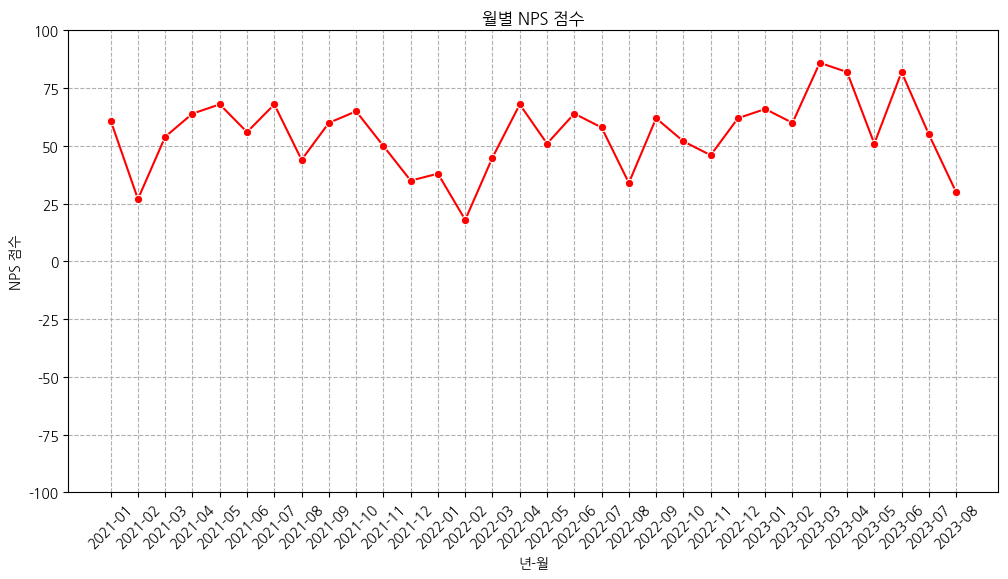

In [43]:
plt.figure(figsize=(12, 6))

nps_counts['Date_String'] = nps_counts.index.strftime('%Y-%m')

sns.lineplot(x=nps_counts['Date_String'],
             y=nps_counts['NPS_Score'],
             marker='o',
             color='red')

plt.title('월별 NPS 점수')
plt.xlabel('년-월')
plt.ylabel('NPS 점수')
plt.xticks(rotation=45)
plt.ylim(-100, 100)

plt.grid(axis='both',
         linestyle='--')
plt.show()

### **세부 평점 항목과 '종합 평점'의 월별 평균값 시각화**

In [48]:
monthly_avg_rating_df = df.groupby('숙박 날짜')[RATING_COLS].mean().reset_index()
monthly_avg_rating_df['숙박 날짜'] = monthly_avg_rating_df['숙박 날짜'].astype(str)
monthly_avg_rating_df.head()

,숙박 날짜,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
0,2021-01,4.527778,4.272727,4.727273,4.818182,4.656250,4.454545,4.212121
1,2021-02,3.838710,3.879310,4.189655,4.482759,4.327586,4.051724,3.844828
2,2021-03,4.392157,4.220000,4.480000,4.800000,4.540000,4.600000,4.380000
3,2021-04,4.568627,4.425532,4.531915,4.787234,4.787234,4.787234,4.702128
4,2021-05,4.537037,3.921569,4.380000,4.705882,4.673469,4.620000,4.461538


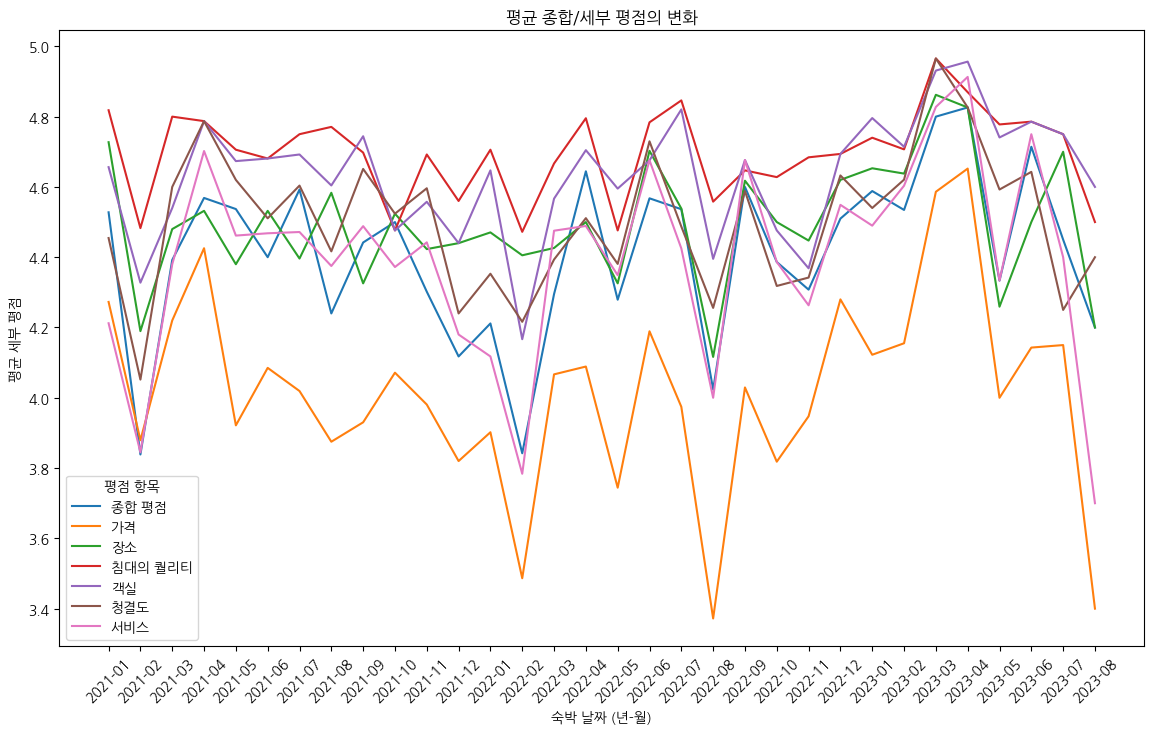

In [ ]:
# 종합 평점, 세부 평점 모두 비슷한 경향을 띈다.
# 2월, 8월은 성수기 시즌이라 낮을 수 있음.
plt.figure(figsize=(14, 8))

for col in RATING_COLS:
    sns.lineplot(data=monthly_avg_rating_df,
                 x='숙박 날짜',
                 y=col,
                 label=col)
    
plt.title('평균 종합/세부 평점의 변화')
plt.xlabel('숙박 날짜 (년-월)')
plt.ylabel('평균 세부 평점')
plt.xticks(rotation=45)

plt.legend(title='평점 항목')
plt.show()

### **월별 전체/부정적 리뷰 수 패턴 시각화**

In [56]:
monthly_review_df = df.groupby('숙박 날짜').agg(
                        전체_리뷰_수 = pd.NamedAgg(column='리뷰ID', aggfunc='count'),
                        부정적_리뷰_수 = pd.NamedAgg(column='종합 평점', aggfunc=lambda x: (x <= 3).sum())
                    ).reset_index()
monthly_review_df['숙박 날짜'] = monthly_review_df['숙박 날짜'].astype(str)
monthly_review_df.head(10)

,숙박 날짜,전체_리뷰_수,부정적_리뷰_수
0,2021-01,36,5
1,2021-02,62,20
2,2021-03,51,7
3,2021-04,51,7
4,2021-05,54,6
5,2021-06,50,8
6,2021-07,54,7
7,2021-08,50,10
8,2021-09,43,6
9,2021-10,44,4


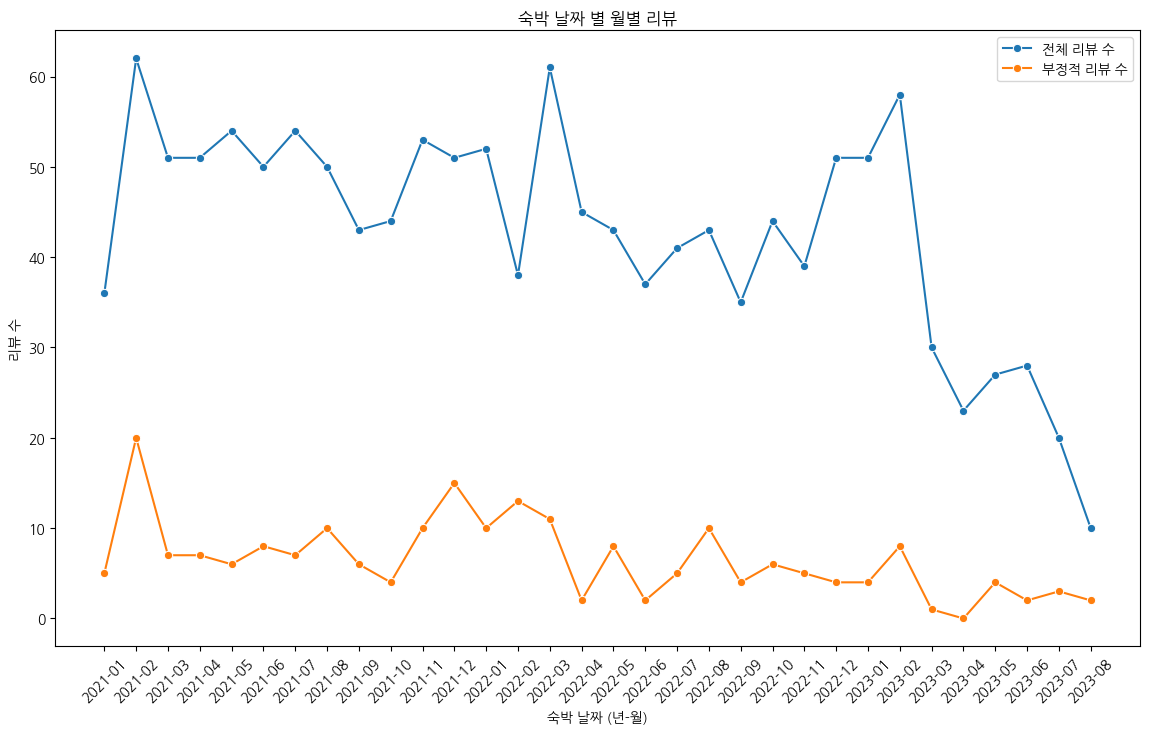

In [58]:
plt.figure(figsize=(14, 8))

sns.lineplot(data=monthly_review_df,
             x='숙박 날짜',
             y='전체_리뷰_수',
             label='전체 리뷰 수',
             marker='o')
sns.lineplot(data=monthly_review_df,
             x='숙박 날짜',
             y='부정적_리뷰_수',
             label='부정적 리뷰 수',
             marker='o')

plt.title('숙박 날짜 별 월별 리뷰')
plt.xlabel('숙박 날짜 (년-월)')
plt.ylabel('리뷰 수')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# 전체적인 패턴을 확인하기 위해 Min-Max 정규화
monthly_review_df['전체_리뷰_수_정규화'] = (monthly_review_df['전체_리뷰_수'] - monthly_review_df['전체_리뷰_수'].min()) / (monthly_review_df['전체_리뷰_수'].max() - monthly_review_df['전체_리뷰_수'].min())
monthly_review_df['부정적_리뷰_수_정규화'] = (monthly_review_df['부정적_리뷰_수'] - monthly_review_df['부정적_리뷰_수'].min()) / (monthly_review_df['부정적_리뷰_수'].max() - monthly_review_df['부정적_리뷰_수'].min())
monthly_review_df.head(10)

,숙박 날짜,전체_리뷰_수,부정적_리뷰_수,전체_리뷰_수_정규화,부정적_리뷰_수_정규화
0,2021-01,36,5,0.500000,0.25
1,2021-02,62,20,1.000000,1.00
2,2021-03,51,7,0.788462,0.35
3,2021-04,51,7,0.788462,0.35
4,2021-05,54,6,0.846154,0.30
5,2021-06,50,8,0.769231,0.40
6,2021-07,54,7,0.846154,0.35
7,2021-08,50,10,0.769231,0.50
8,2021-09,43,6,0.634615,0.30
9,2021-10,44,4,0.653846,0.20


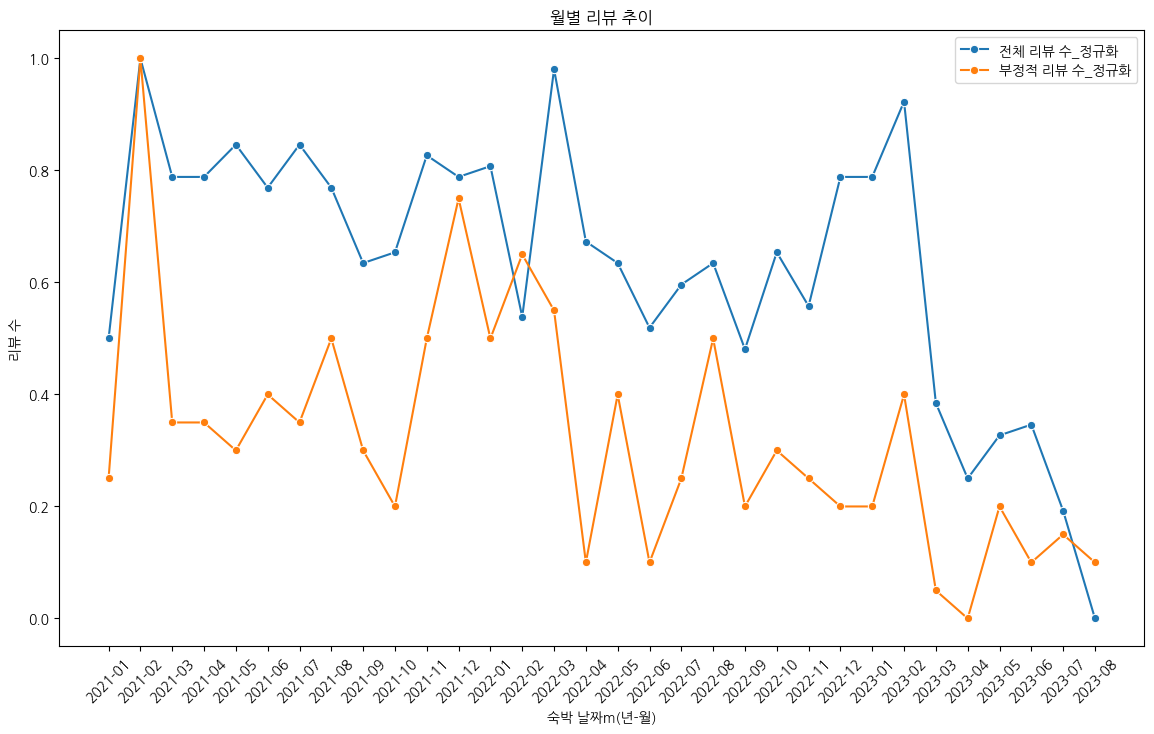

In [60]:
plt.figure(figsize=(14, 8))

sns.lineplot(data=monthly_review_df,
             x='숙박 날짜',
             y='전체_리뷰_수_정규화',
             label='전체 리뷰 수_정규화',
             marker='o')
sns.lineplot(data=monthly_review_df,
             x='숙박 날짜',
             y='부정적_리뷰_수_정규화',
             label='부정적 리뷰 수_정규화',
             marker='o')

plt.title('월별 리뷰 추이')
plt.xlabel('숙박 날짜m(년-월)')
plt.ylabel('리뷰 수')
plt.xticks(rotation=45)

plt.show()

### **부정적 리뷰에 대한 세부 평점 항목의 월별 평균값 시각화**

In [68]:
detractor_review_df = df[df['NPS_Category'] == 'Detrector']
monthly_avg_detractor_review_df = detractor_review_df.groupby('숙박 날짜')[RATING_COLS].mean().reset_index()
monthly_avg_detractor_review_df['숙박 날짜'] = monthly_avg_detractor_review_df['숙박 날짜'].astype(str)
monthly_avg_detractor_review_df.head(10)

,숙박 날짜,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
0,2021-01,2.400000,4.000000,4.200000,4.600000,3.600000,2.400000,1.800000
1,2021-02,1.650000,2.352941,2.882353,3.588235,3.000000,2.411765,1.529412
2,2021-03,1.857143,2.571429,3.571429,4.000000,2.571429,2.857143,2.142857
3,2021-04,2.428571,3.400000,3.200000,3.400000,3.600000,3.600000,2.800000
4,2021-05,1.666667,1.800000,3.200000,2.800000,2.800000,2.000000,1.200000
5,2021-06,2.000000,2.857143,3.285714,3.428571,3.142857,3.142857,2.142857
6,2021-07,2.285714,2.166667,3.000000,3.833333,2.833333,3.285714,2.000000
7,2021-08,2.000000,2.375000,3.625000,4.125000,2.875000,2.875000,2.375000
8,2021-09,1.833333,2.166667,2.166667,3.500000,4.166667,4.000000,2.666667
9,2021-10,1.250000,2.500000,3.250000,3.000000,2.000000,3.000000,1.250000


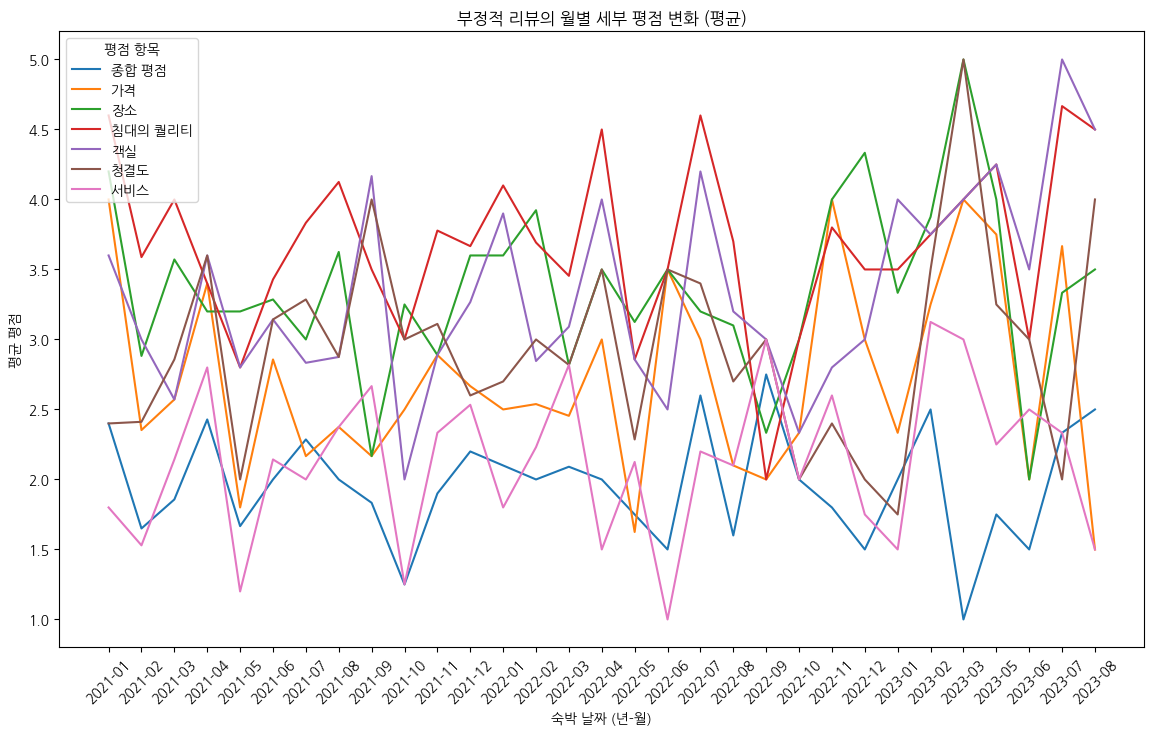

In [77]:
plt.figure(figsize=(14, 8))

for col in RATING_COLS:
    sns.lineplot(data=monthly_avg_detractor_review_df,
                 x='숙박 날짜',
                 y=col,
                 label=col)

plt.title('부정적 리뷰의 월별 세부 평점 변화 (평균)')
plt.xlabel('숙박 날짜 (년-월)')
plt.ylabel('평균 평점')
plt.xticks(rotation=45)

plt.legend(title='평점 항목',loc='upper left')
plt.show()

### **부정적 리뷰에서의 각 세부 평점 항목과 종합 평점간의 상관 계수**
[ 피어슨 상관 계수 ]

두 변수간의 선형 상관 관계의 강도와 방향을 측정한 수치

- 1: 완벽한 양의 선형 상관 관계
- 0: 선형 상관 관계 없음
- -1: 완벽한 음의 선형 상관 관계

In [79]:
corr_matrix = detractor_review_df[RATING_COLS].corr()
corr_matrix

,종합 평점,가격,장소,침대의 퀄리티,객실,청결도,서비스
종합 평점,1.000000,0.291753,0.136066,0.264830,0.382423,0.334523,0.489507
가격,0.291753,1.000000,0.452307,0.491955,0.371244,0.410563,0.193200
장소,0.136066,0.452307,1.000000,0.410768,0.339694,0.226919,0.182972
침대의 퀄리티,0.264830,0.491955,0.410768,1.000000,0.546202,0.379470,0.172558
객실,0.382423,0.371244,0.339694,0.546202,1.000000,0.577863,0.272274
청결도,0.334523,0.410563,0.226919,0.379470,0.577863,1.000000,0.238744
서비스,0.489507,0.193200,0.182972,0.172558,0.272274,0.238744,1.000000


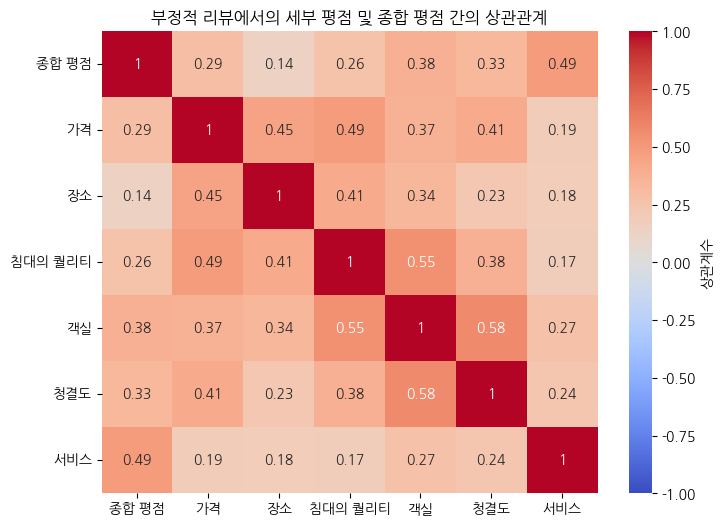

In [ ]:
# 모두 양의 상관관계를 가지고 있음.
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            annot=True,
            cbar_kws={'label': '상관계수'})

plt.title('부정적 리뷰에서의 세부 평점 및 종합 평점 간의 상관관계')
plt.yticks(rotation=0)

plt.show()